[] Adjust Code-Gerüst, for channel interpolation: stick with the usual, checking continuous data and topoplots <br> 
[] Adjust topoplots for the fact that some subjects don't have retrieval events. If too complex, I'll use PSD instead, but I really think event-specific is better <br> 
[] Run script for subjects of different categories (behavioral exclusion, missing retrieval eeg data: 03, missing single behavioral trials: ...<br> 
[] Add comments <br> 

In [ ]:
import mne
import pandas as pd
import json
from pathlib import Path
from mne_bids import BIDSPath, read_raw_bids

# ==========================================
# 1. DEFINE CURRENT SUBJECT
# ==========================================
# Change this ID for every participant you want to inspect
subj = "03" 

# ==========================================
# 2. DEFINE PATHS & LOAD EXCLUSIONS
# ==========================================
# Adjust these paths to match your project structure
project_root = Path.cwd().parent.parent
bids_root = project_root / "data" / "bids"
derivatives_dir = project_root / "data" / "derivatives"

# Load json object with subjects that should be entirely excluded from the analysis
exclusion_file = derivatives_dir / "subject_exclusions.json"

with open(exclusion_file, "r") as f:
    exclusions = json.load(f)

# Use .get() to safely load the list, defaulting to an empty list if the key is missing
behavioral_exclusions = exclusions.get("behavioral_exclusions", [])

print("The following subjects are marked for exclusion based on behavioral criteria:")
print(behavioral_exclusions)

# Path to our central configuration file
config_path = derivatives_dir / "preprocessing_config.csv"

# ==========================================
# 3. LOAD OR CREATE CONFIGURATION FILE
# ==========================================
if config_path.exists():
    df_config = pd.read_csv(config_path, dtype={'subject': str})
    print(f"\nExisting config loaded. {len(df_config)} subjects inspected so far.")
else:
    df_config = pd.DataFrame(columns=[
        "subject", 
        "is_excluded", 
        "eeg_enc_recorded", 
        "eeg_ret_recorded", 
        "beh_enc_complete", 
        "beh_ret_complete",
        "bad_channels", 
        "manual_bad_icas", 
        "notes_exclusion", 
        "notes_beh", 
        "notes_eeg"
    ])
    print("\nNo existing config found. Creating a new detailed metadata table.")

# ==========================================
# 4. SAFETY CHECK & AUTO-LOGGING
# ==========================================
# Check if the current subject is in the exclusion list
subject_is_excluded = subj in behavioral_exclusions

if subject_is_excluded:
    # 4a. Throw a highly visible warning
    print("\n" + "!"*65)
    print(f" WARNING: Subject {subj} is in the behavioral_exclusions list!")
    print("!"*65)
    
    # 4b. Automatically log this into the config dataframe
    auto_notes = "Auto-excluded: Behavioral criteria not met."
    
    if subj in df_config['subject'].values:
        idx = df_config.index[df_config['subject'] == subj].tolist()[0]
        df_config.loc[idx, 'is_excluded'] = True
        df_config.loc[idx, 'notes'] = auto_notes
    else:
        new_row = pd.DataFrame([{
            "subject": subj, 
            "is_excluded": True,
            "bad_channels": "", 
            "manual_bad_icas": "",
            "notes": auto_notes
        }])
        df_config = pd.concat([df_config, new_row], ignore_index=True)
        
    # 4c. Save immediately so you don't need to run the final cell
    df_config.to_csv(config_path, index=False)
    print(f"\n--> Action taken: Subject {subj} automatically marked as excluded in the config.")
    print("--> You can SKIP the rest of the cells in this notebook for this subject.")

else:
    print(f"\n--> Subject {subj} is clear for preprocessing. Proceed to the next cells.")

The following subjects are marked for exclusion based on behavioral criteria:
['05', '06', '07', '08', '13', '14', '16', '18', '19', '24', '25', '28', '31', '34', '39', '40']

No existing config found. Creating a new detailed metadata table.

--> Subject 03 is clear for preprocessing. Proceed to the next cells.


In [53]:
import mne
import pandas as pd
import json
from pathlib import Path
from mne_bids import BIDSPath, read_raw_bids

# ==========================================
# 1. DEFINE CURRENT SUBJECT
# ==========================================
# Change this ID for every participant you want to inspect
subj = "03" 

# ==========================================
# 2. DEFINE PATHS & LOAD EXCLUSIONS
# ==========================================
# Adjust these paths to match your project structure
project_root = Path.cwd().parent.parent
bids_root = project_root / "data" / "bids"
derivatives_dir = project_root / "data" / "derivatives"

# Load json object with subjects that should be entirely excluded from the analysis
exclusion_file = derivatives_dir / "subject_exclusions.json"

with open(exclusion_file, "r") as f:
    exclusions = json.load(f)

# Use .get() to safely load the list, defaulting to an empty list if the key is missing
behavioral_exclusions = exclusions.get("behavioral_exclusions", [])

print("The following subjects are marked for exclusion based on behavioral criteria:")
print(behavioral_exclusions)

# Path to our central configuration file
config_path = derivatives_dir / "preprocessing_config.csv"

# ==========================================
# 3. LOAD OR CREATE CONFIGURATION FILE
# ==========================================
if config_path.exists():
    df_config = pd.read_csv(config_path, dtype={'subject': str})
    print(f"\nExisting config loaded. {len(df_config)} subjects inspected so far.")
else:
    df_config = pd.DataFrame(columns=[
        "subject", 
        "is_excluded", 
        "eeg_enc_recorded", 
        "eeg_ret_recorded", 
        "beh_enc_complete", 
        "beh_ret_complete",
        "bad_channels", 
        "manual_bad_icas", 
        "notes_exclusion", 
        "notes_beh", 
        "notes_eeg"
    ])
    print("\nNo existing config found. Creating a new detailed metadata table.")

# ==========================================
# 4. SAFETY CHECK & AUTO-LOGGING
# ==========================================
# Check if the current subject is in the exclusion list
subject_is_excluded = subj in behavioral_exclusions

if subject_is_excluded:
    # 4a. Throw a highly visible warning
    print("\n" + "!"*65)
    print(f" WARNING: Subject {subj} is in the behavioral_exclusions list!")
    print("!"*65)
    
    # 4b. Automatically log this into the config dataframe
    auto_notes = "Auto-excluded: Behavioral criteria not met."
    
    if subj in df_config['subject'].values:
        idx = df_config.index[df_config['subject'] == subj].tolist()[0]
        df_config.loc[idx, 'is_excluded'] = True
        df_config.loc[idx, 'notes'] = auto_notes
    else:
        new_row = pd.DataFrame([{
            "subject": subj, 
            "is_excluded": True,
            "bad_channels": "", 
            "manual_bad_icas": "",
            "notes": auto_notes
        }])
        df_config = pd.concat([df_config, new_row], ignore_index=True)
        
    # 4c. Save immediately so you don't need to run the final cell
    df_config.to_csv(config_path, index=False)
    print(f"\n--> Action taken: Subject {subj} automatically marked as excluded in the config.")
    print("--> You can SKIP the rest of the cells in this notebook for this subject.")

else:
    print(f"\n--> Subject {subj} is clear for preprocessing. Proceed to the next cells.")

The following subjects are marked for exclusion based on behavioral criteria:
['05', '06', '07', '08', '13', '14', '16', '18', '19', '24', '25', '28', '31', '34', '39', '40']

No existing config found. Creating a new detailed metadata table.

--> Subject 03 is clear for preprocessing. Proceed to the next cells.


C:\Users\noahm\AppData\Local\Temp\ipykernel_26776\3938984023.py:21: RuntimeWarning: More events than default colors available. You should pass a list of unique colors.
  fig_ev = mne.viz.plot_events(


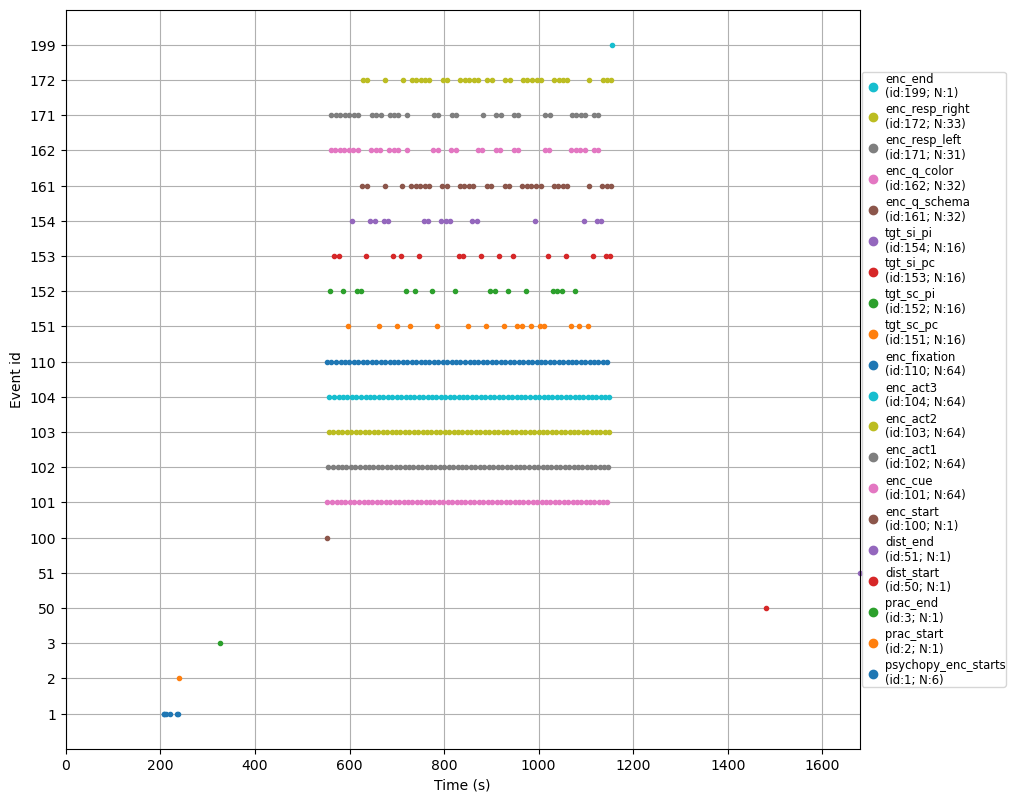

In [ ]:
# ==========================================
# 4. LOAD BIDS DATA
# ==========================================
bids_path = BIDSPath(subject=subj, task='loc', datatype='eeg', root=bids_root)

# 2. Load Raw
raw_eeg, bids_event_id = read_raw_bids(
    bids_path=bids_path, 
    return_event_dict=True,  # <--- HIER: Extrahiert das Mapping direkt aus BIDS
    verbose='error'
)
# 3. Load events
events, event_id = mne.events_from_annotations(
    raw_eeg, 
    event_id=bids_event_id,  # <--- Überschreibt den "auto" Parser
    verbose=False
)

# 4. Plot event markers as function of experiment run time
fig_ev = mne.viz.plot_events(
    events, 
    sfreq=raw_eeg.info["sfreq"], 
    first_samp=raw_eeg.first_samp, 
    event_id=event_id
)

In [56]:
# ==========================================
# 4. LOAD BIDS DATA
# ==========================================
bids_path = BIDSPath(subject=subj, task='loc', datatype='eeg', root=bids_root)
raw = read_raw_bids(bids_path, verbose='error')
raw.load_data()

# Create a copy with basic filters for easier visual inspection
# (1Hz highpass removes slow drifts, 50/60Hz notch removes line noise)
raw_inspect = raw.copy().filter(l_freq=1.0, h_freq=None).notch_filter(50) 

# ==========================================
# 5. VISUAL INSPECTION (CHANNELS)
# ==========================================
print(f"Inspecting subject: {subj}")

# Step 5b: Plot time series 
# (Click on a channel name in the plot to mark it as 'bad'. Press 'b' for butterfly view)
raw_inspect.plot(
    duration=10, 
    n_channels=32, 
    scalings=dict(eeg=20e-6),
    theme="light" 
)

# MNE remembers which channels you clicked:
print(f"Bad channels marked during inspection: {raw_inspect.info['bads']}")

Reading 0 ... 2982939  =      0.000 ...  2982.939 secs...
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 3301 samples (3.301 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 d

Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


c:\Users\noahm\mne-python\1.11.0_0\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


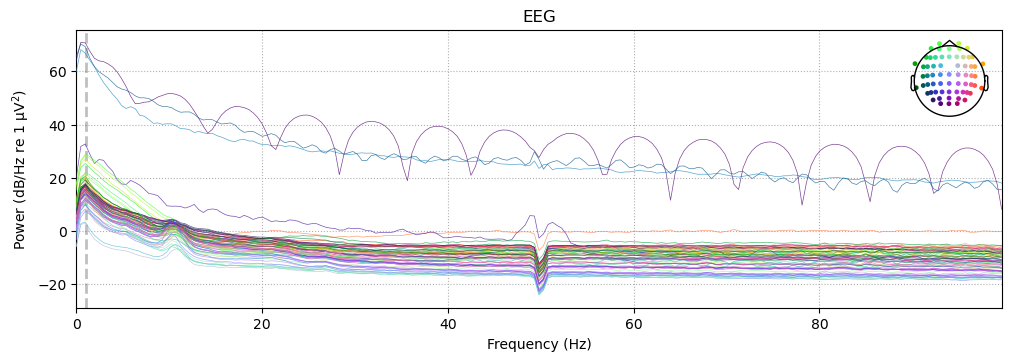

In [ ]:
# Step 5a: Plot Power Spectral Density (PSD) to spot consistently noisy channels
raw_inspect.compute_psd(fmax=100).plot()


No bad channels marked yet. Generating diagnostic plots...
Plotting topomap for event: 'enc_fixation' (ID: 110)
Not setting metadata
64 matching events found
Setting baseline interval to [-0.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated


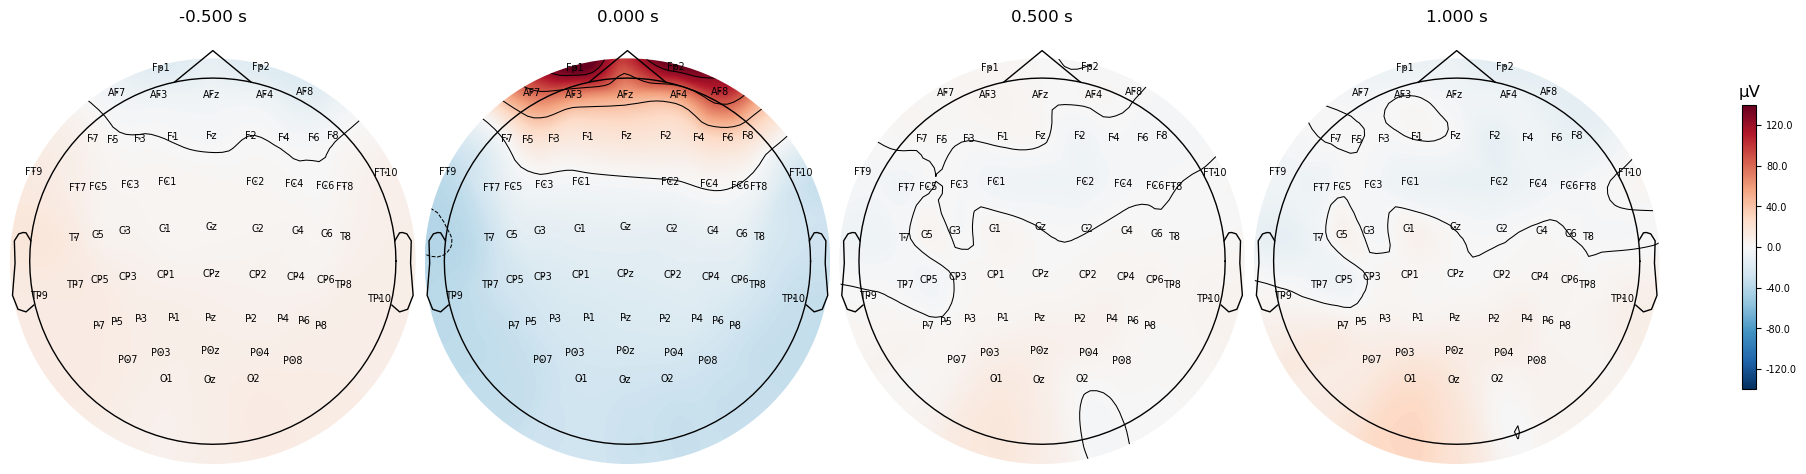

ValueError: Could not find any of the events you specified.

In [ ]:
# 1. Check if bads are already marked
current_bads = raw_eeg.info['bads']

if len(current_bads) > 0:
    print(f"Bad channels are already marked: {current_bads}")
    print("Skipping automatic visualization. (If you want to re-check, clear 'raw_eeg.info['bads']' first).")

else:
    print("No bad channels marked yet. Generating diagnostic plots...")

    # 2. Define both events as list of tuples: (name, id)
    target_events = [
        ('enc_fixation', 110),
        ('ret_fixation', 210),

    for event_name, event_id in target_events:

        # 3. Extract events for this specific event only
        events, _ = mne.events_from_annotations(
            raw,
            event_id={event_name: event_id},
            verbose=False
        )

        # 4. Check if the target ID exists
        if event_id not in events[:, 2]:
            print(f"Warning: Event ID {event_id} ('{event_name}') not found. Skipping.")
            continue

        print(f"Plotting topomap for event: '{event_name}' (ID: {event_id})")

        # 5. Create Epochs
        epochs_viz = mne.Epochs(
            raw_eeg,
            events,
            event_id={event_name: event_id},
            tmin=-0.5, tmax=1,
            # baseline=(None, 0),
            # preload=True,
            reject_by_annotation=True,
            # verbose=False
        )

        # 6. Plot Topomap
        #    Look for "Red" or "Blue" spots that look completely different from neighbors
        fig_topo = epochs_viz.average().plot_topomap(
            show_names=True,
            size=3,
            nrows = 1  # Zur Unterscheidung
        )

In [ ]:
# ==========================================
# 6. RUN INDEPENDENT COMPONENT ANALYSIS (ICA)
# ==========================================
# Transfer bad channels from the visual inspection so ICA ignores them
raw.info['bads'] = raw_inspect.info['bads']

# Create a new copy for ICA (1Hz highpass is highly recommended for ICA)
raw_ica = raw.copy().filter(l_freq=1.0, h_freq=None)

# Initialize and fit ICA
from mne.preprocessing import ICA
ica = ICA(n_components=15, random_state=97, max_iter='auto')
ica.fit(raw_ica)

# ==========================================
# 7. AUTOMATED EOG DETECTION & VISUALIZATION
# ==========================================
# Let MNE suggest EOG components based on your dedicated EOG channels
eog_indices, eog_scores = ica.find_bads_eog(raw_ica)
print(f"MNE automatically identified these ICs as EOG artifacts: {eog_indices}")

# Plot components (Topographies)
ica.plot_components()

# Plot ICA sources over time (Time series)
# You can click on the IC name here to mark it as bad, but we will explicitly
# write down any ADDITIONAL bad ICs in the next cell to save them.
ica.plot_sources(raw_ica, block=True)

In [ ]:
# ==========================================
# 8. LOG YOUR MANUAL DECISIONS & METADATA
# ==========================================
# Check if the subject is in your predefined full-exclusion list
subject_is_excluded = subj in behavioral_exclusions

# A. Phase Completion Flags (Booleans)
# Change these to False if a specific phase is missing or corrupted
my_eeg_enc_recorded = True
my_eeg_ret_recorded = False
my_beh_enc_complete = True
my_beh_ret_complete = True

# B. Bad Channels & ICAs
my_bad_channels = raw.info['bads'] if not subject_is_excluded else []
my_manual_icas = [] 

# C. Targeted Notes
my_notes_exclusion = "Auto-excluded: Behavioral criteria not met." if subject_is_excluded else ""
my_notes_beh = ""
my_notes_eeg = "Retrieval triggers missing in raw data; encoding is fine." if subj == "03" else ""

# ==========================================
# 9. FORMAT AND SAVE TO CSV
# ==========================================
bads_str = ", ".join(my_bad_channels) if my_bad_channels else ""
icas_str = ", ".join(map(str, my_manual_icas)) if my_manual_icas else ""

# Prepare the dictionary for the current subject
row_data = {
    "subject": subj, 
    "is_excluded": subject_is_excluded,
    "eeg_enc_recorded": my_eeg_enc_recorded,
    "eeg_ret_recorded": my_eeg_ret_recorded,
    "beh_enc_complete": my_beh_enc_complete,
    "beh_ret_complete": my_beh_ret_complete,
    "bad_channels": bads_str, 
    "manual_bad_icas": icas_str,
    "notes_exclusion": my_notes_exclusion,
    "notes_beh": my_notes_beh,
    "notes_eeg": my_notes_eeg
}

if subj in df_config['subject'].values:
    # Update the existing row using the index
    idx = df_config.index[df_config['subject'] == subj].tolist()[0]
    for key, value in row_data.items():
        df_config.loc[idx, key] = value
    print(f"--> Metadata for sub-{subj} successfully updated.")
else:
    # Append a new row
    new_row = pd.DataFrame([row_data])
    df_config = pd.concat([df_config, new_row], ignore_index=True)
    print(f"--> New metadata entry for sub-{subj} successfully added.")

df_config.to_csv(config_path, index=False)
display(df_config.tail())